In [1]:
# =============================================================================
# LOC_IF_SHAP_fix — Isolation Forest + SHAP for Hospital Outlier Detection
# =============================================================================
# This notebook is a methodological fix of LOC_IF_SHAP_v5.
# Each fix is annotated with # FIX #N: explaining what changed and why.
#
# Fixes applied:
#   1. Removed StandardScaler (IF doesn't need it; distorts SHAP interpretation)
#   2. Score-based 2σ threshold replaces fixed contamination=0.05
#   3. SHAP values now in original feature space (consequence of Fix #1)
#   4. Single pooled model trained on both years (cross-year comparability)
#   5. driver_dev_pct renamed/annotated — raw count space for log features
#   6. SQL HAVING clauses aligned (both use case_count >= 30)
#   7. 2026 month range limited to 202601–202604
# =============================================================================
from sqlalchemy import create_engine
from snowflake.sqlalchemy import URL
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import shap

c:\Users\knguy139\Documents\Projects\.venv\Lib\site-packages\snowflake\connector\vendored\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(
c:\Users\knguy139\Documents\Projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# =============================================================================
# SNOWFLAKE CONNECTION
# =============================================================================
engine = create_engine(URL(
    account = "UHG-UHGDWAAS",
    user = "KHANG.NGUYEN@UHC.COM",
    authenticator = "externalbrowser",
    role = "AZU_SDRP_VING_PRD_DEVELOPER_ROLE",
    warehouse = "VING_PRD_MNR_HCE_DATAINFRA_WH",
    database = "VING_PRD_TREND_DB",
    schema = "TMP_1M"
))

In [3]:
# =============================================================================
# 2025 DATA PULL
# =============================================================================
# FIX #6: HAVING clause now uses count(distinct case_id) >= 30 (same as Python
#   eligibility filter). Previously v5's 2026 pull used a different HAVING on
#   ADR count, creating asymmetry. Both years now use identical SQL filters.
# =============================================================================
df_2025 = pd.read_sql("""
    select
        d.collection as hospital_group
        , a.fin_market
        , count(distinct a.case_id) as case_count
        , count(distinct case when a.initialfulladr_cases = 1 then a.case_id end) as initial_adr_cnt
        , count(distinct case when a.persistentfulladr_cases = 1 then a.case_id end) as persistent_adr_cnt
        , count(distinct case when a.p2p_full_ovtn = 1 then a.case_id end) as p2p_ovrtn_cnt
        , count(distinct case when a.appeal_ovrtn_ind = 1 then a.case_id end) as appeal_ovrtn_cnt
        , count(distinct case when a.mcr_ovtrn_ind = 1 then a.case_id end) as mcr_ovrtn_cnt
        , count(distinct case when a.icm_md_reviewed_ind = 1 then a.case_id end) as md_reviewed_cnt
    from tmp_1m.ec_avtar_25_26_3_od as a
    left join tmp_1y.tin_collection as d
        on substr(a.fa_prov_id, 2, 9) = d.tin
    where fin_brand = 'M&R'
        and (
            (ip_type in ('Medical', 'Surgical', 'Transplant')
             and to_varchar(admit_dt_act, 'MM/dd/yyyy') is not null)
            or ip_type in ('LTAC', 'SNF', 'AIR')
        )
        and loc_flag = 1
        and (
            (global_cap = 'NA' and sgr_source_name = 'COSMOS'
             and fin_product_level_3 != 'INSTITUTIONAL' and tfm_include_flag = 1)
            or (sgr_source_name = 'NICE' and nce_tadm_dec_risk_type in ('FFS', 'PHYSICIAN'))
        )
        and hce_admit_month between '202501' and '202512'
        and d.collection is not null
    group by 1,2
    having count(distinct a.case_id) >= 30
""", engine)

print(f"df_2025: {df_2025.shape}")

 pip install snowflake-connector-python[secure-local-storage]


Initiating login request with your identity provider. Press CTRL+C to abort and try again...
Going to open: https://login.microsoftonline.com/db05faca-c82a-4b9d-b9c5-0f64b6755421/saml2?SAMLRequest=lVLRbtowFP2VyHtO7KRAwQIqVsTK1m4ZhErry%2BTYDng4drCdpv37OQlI3UMr7cGSZZ9zz7n33OnNSymDZ26s0GoG4giBgCuqmVD7Gdhlq3AMAuuIYkRqxWfglVtwM59aUsoKL2p3UBt%2Bqrl1gS%2BkLG4%2FZqA2CmtihcWKlNxiR%2FF28XCPkwhhYi03zsuBM4VZ4bUOzlUYwqZpouYq0mYPE4QQRBPoUS3kE3gjUX2sURntNNXyQnnxPb0jEUM0aCU8wiukZ%2BJnofoRfKSS9yCL77IsDdMf2wwEi0t3t1rZuuRmy82zoHy3ue8NWO%2BgPuxDf1hDiP19IJFVuikkOXKqy6p2vmbkb7DgDEq9F35S6%2BUMVEfBTnm1%2BipTcfcn1t%2Bqn%2BRxu6zJl3RTpYNNntf59fFUlvvJ7in7RUHweMk1aXNdW1vztWrTdP4JJaMQjcJ4nMVjPIwxuoqGg%2BQJBEufplDEdcyL5c5HVApqtNWF00oKxTuXLEfDglAS0nFCwkE%2BYWE%2BocMQFaNBProe%2BqIxbDNLQL83uDNi5v83jSl8yz0v4HefyXqZainoa7DSpiTu%2FcjiKO5eBAuLDop5SYRcMGa4tT46KXVzazhxfs%2BdqTmA8171302f%2FwU%3D&RelayState=ver%3A3-hint%3A260092117886646-ETMsDgAAAZ7cEov2ABRBRVMvQ0JDL1BLQ1M1UGFkZGluZwEAABAAENxOhwJqc2K3URbocspIulEAAACQUNIoh%2FBq

In [4]:
# =============================================================================
# 2026 DATA PULL
# =============================================================================
# FIX #6: HAVING aligned to count(distinct case_id) >= 30 (was HAVING on ADR
#   count in v5). Python eligibility filter is still the binding one.
# FIX #7: Month range limited to 202601–202604 (was open-ended >= '202601').
# =============================================================================
df_2026 = pd.read_sql("""
    select
        d.collection as hospital_group
        , a.fin_market
        , count(distinct a.case_id) as case_count
        , count(distinct case when a.initialfulladr_cases = 1 then a.case_id end) as initial_adr_cnt
        , count(distinct case when a.persistentfulladr_cases = 1 then a.case_id end) as persistent_adr_cnt
        , count(distinct case when a.p2p_full_ovtn = 1 then a.case_id end) as p2p_ovrtn_cnt
        , count(distinct case when a.appeal_ovrtn_ind = 1 then a.case_id end) as appeal_ovrtn_cnt
        , count(distinct case when a.mcr_ovtrn_ind = 1 then a.case_id end) as mcr_ovrtn_cnt
        , count(distinct case when a.icm_md_reviewed_ind = 1 then a.case_id end) as md_reviewed_cnt
        , count(distinct case when a.member_appeal_ind = 1 then a.case_id end) as member_appeal_cnt
        , count(distinct case when a.member_appeal_ovtn_ind = 1 then a.case_id end) as member_appeal_ovtn_cnt
    from tmp_1m.ec_avtar_25_26_3_od as a
    left join tmp_1y.tin_collection as d
        on substr(a.fa_prov_id, 2, 9) = d.tin
    where fin_brand = 'M&R'
        and (
            (ip_type in ('Medical', 'Surgical', 'Transplant')
             and to_varchar(admit_dt_act, 'MM/dd/yyyy') is not null)
            or ip_type in ('LTAC', 'SNF', 'AIR')
        )
        and loc_flag = 1
        and (
            (global_cap = 'NA' and sgr_source_name = 'COSMOS'
             and fin_product_level_3 != 'INSTITUTIONAL' and tfm_include_flag = 1)
            or (sgr_source_name = 'NICE' and nce_tadm_dec_risk_type in ('FFS', 'PHYSICIAN'))
        )
        and hce_admit_month between '202601' and '202604'
        and d.collection is not null
    group by 1,2
    having count(distinct a.case_id) >= 30
""", engine)

engine.dispose()
print(f"df_2026: {df_2026.shape}")

df_2026: (1026, 11)


In [ ]:
# =============================================================================
# COMPUTE RATES + EMPIRICAL BAYES SHRINKAGE + LOG-VOLUME (both years)
# =============================================================================

def compute_rates_and_shrinkage(df, year, has_member_appeal = False):
    df = df.assign(
        initial_adr_rate = lambda x: x.initial_adr_cnt / x.case_count,
        persistent_adr_rate = lambda x: x.persistent_adr_cnt / x.case_count,
        p2p_overturn_rate = lambda x: x.p2p_ovrtn_cnt / x.initial_adr_cnt.replace(0, np.nan),
        appeal_overturn_rate = lambda x: x.appeal_ovrtn_cnt / x.initial_adr_cnt.replace(0, np.nan),
        mcr_overturn_rate = lambda x: x.mcr_ovrtn_cnt / x.initial_adr_cnt.replace(0, np.nan),
        md_review_rate = lambda x: x.md_reviewed_cnt / x.case_count,
    )
    if has_member_appeal:
        df = df.assign(
            member_appeal_rate = lambda x: x.member_appeal_cnt / x.initial_adr_cnt.replace(0, np.nan),
        )

    rate_cols = [
        "initial_adr_rate", "persistent_adr_rate", "p2p_overturn_rate",
        "appeal_overturn_rate", "mcr_overturn_rate", "md_review_rate",
    ]
    if has_member_appeal:
        rate_cols.append("member_appeal_rate")

    count_cols = [
        "case_count", "initial_adr_cnt", "persistent_adr_cnt",
        "p2p_ovrtn_cnt", "appeal_ovrtn_cnt", "mcr_ovrtn_cnt", "md_reviewed_cnt"
    ]
    if has_member_appeal:
        count_cols += ["member_appeal_cnt", "member_appeal_ovtn_cnt"]

    df[rate_cols + count_cols] = df[rate_cols + count_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

    df_iso = df.query("case_count >= 30 and initial_adr_cnt >= 10").copy()
    raw_medians = df_iso[rate_cols].median()

    k = 50
    gr_initial_adr = df_iso["initial_adr_cnt"].sum() / df_iso["case_count"].sum()
    gr_persistent = df_iso["persistent_adr_cnt"].sum() / df_iso["case_count"].sum()
    gr_p2p = df_iso["p2p_ovrtn_cnt"].sum() / df_iso["initial_adr_cnt"].sum()
    gr_appeal = df_iso["appeal_ovrtn_cnt"].sum() / df_iso["initial_adr_cnt"].sum()
    gr_mcr = df_iso["mcr_ovrtn_cnt"].sum() / df_iso["initial_adr_cnt"].sum()
    gr_md = df_iso["md_reviewed_cnt"].sum() / df_iso["case_count"].sum()

    df_iso = df_iso.assign(
        initial_adr_adj_rate = lambda x: (x.initial_adr_cnt + k * gr_initial_adr) / (x.case_count + k),
        persistent_adr_adj_rate = lambda x: (x.persistent_adr_cnt + k * gr_persistent) / (x.case_count + k),
        p2p_overturn_adj_rate = lambda x: (x.p2p_ovrtn_cnt + k * gr_p2p) / (x.initial_adr_cnt + k),
        appeal_overturn_adj_rate = lambda x: (x.appeal_ovrtn_cnt + k * gr_appeal) / (x.initial_adr_cnt + k),
        mcr_overturn_adj_rate = lambda x: (x.mcr_ovrtn_cnt + k * gr_mcr) / (x.initial_adr_cnt + k),
        md_review_adj_rate = lambda x: (x.md_reviewed_cnt + k * gr_md) / (x.case_count + k),
        log_case_count = lambda x: np.log1p(x.case_count),
        log_initial_adr_cnt = lambda x: np.log1p(x.initial_adr_cnt),
    )
    if has_member_appeal:
        gr_member_appeal = df_iso["member_appeal_cnt"].sum() / df_iso["initial_adr_cnt"].sum()
        df_iso = df_iso.assign(
            member_appeal_adj_rate = lambda x: (x.member_appeal_cnt + k * gr_member_appeal) / (x.initial_adr_cnt + k),
        )

    df_iso["year"] = year
    return df_iso, raw_medians, rate_cols, count_cols

df_iso_25, raw_medians_25, rate_cols_25, count_cols_25 = compute_rates_and_shrinkage(df_2025, "2025", has_member_appeal = False)
df_iso_26, raw_medians_26, rate_cols_26, count_cols_26 = compute_rates_and_shrinkage(df_2026, "2026", has_member_appeal = True)

print(f"2025 IF-ready: {df_iso_25.shape[0]} hospitals")
print(f"2026 IF-ready: {df_iso_26.shape[0]} hospitals")

2025 IF-ready: 1226 hospitals
2026 IF-ready: 790 hospitals


In [31]:
# =============================================================================
# FIX #4: SINGLE POOLED MODEL — train one IF on both years combined
# =============================================================================
# WHY: In v5, each year had its own IF model with its own decision boundaries.
#   A hospital ranked #3 in 2025 and #3 in 2026 isn't equally anomalous because
#   the score distributions differ. A pooled model ensures scores are on the
#   same scale and cross-year comparisons are valid.
#
# APPROACH: Use 9 features including member_appeal_adj_rate. For 2025 (where
#   member_appeal didn't exist as a mechanism), impute with the 2026 global
#   rate (0.0336). This places all 2025 hospitals at center-mass on this
#   dimension — the IF won't split on a feature with zero variance, so
#   member_appeal contributes ~0 SHAP for 2025 rows while remaining active
#   for 2026. This avoids the zero-fill bias (where 0.0 < global rate would
#   make 2025 look artificially "low" on member appeals).
# =============================================================================

iso_kpi = [
    "log_case_count", "log_initial_adr_cnt",
    "initial_adr_adj_rate", "persistent_adr_adj_rate", "p2p_overturn_adj_rate",
    "appeal_overturn_adj_rate", "mcr_overturn_adj_rate", "md_review_adj_rate",
    "member_appeal_adj_rate"
]

gr_member_appeal_26 = df_iso_26["member_appeal_cnt"].sum() / df_iso_26["initial_adr_cnt"].sum()

df_iso_25["member_appeal_adj_rate"] = gr_member_appeal_26

for col in iso_kpi:
    if col not in df_iso_26.columns:
        df_iso_26[col] = 0.0

df_pooled = pd.concat([df_iso_25, df_iso_26], ignore_index = False)
df_pooled[iso_kpi] = df_pooled[iso_kpi].replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"Pooled: {df_pooled.shape[0]} hospital-years, {len(iso_kpi)} features")
print(f"  2025: {(df_pooled['year'] == '2025').sum()} (member_appeal imputed at global rate {gr_member_appeal_26:.4f})")
print(f"  2026: {(df_pooled['year'] == '2026').sum()} (member_appeal observed)")
print(f"  Verify 2025 member_appeal_adj_rate: {df_pooled.loc[df_pooled['year'] == '2025', 'member_appeal_adj_rate'].unique()}")

Pooled: 2016 hospital-years, 9 features
  2025: 1226 (member_appeal imputed at global rate 0.0336)
  2026: 790 (member_appeal observed)
  Verify 2025 member_appeal_adj_rate: [0.03355629]


In [32]:
df_pooled

,hospital_group,fin_market,case_count,initial_adr_cnt,persistent_adr_cnt,p2p_ovrtn_cnt,appeal_ovrtn_cnt,mcr_ovrtn_cnt,md_reviewed_cnt,initial_adr_rate,...,appeal_overturn_adj_rate,mcr_overturn_adj_rate,md_review_adj_rate,log_case_count,log_initial_adr_cnt,year,member_appeal_adj_rate,member_appeal_cnt,member_appeal_ovtn_cnt,member_appeal_rate
4,HCA INC,GA,5506,2140,966,1003,11,72,4153,0.388667,...,0.005195,0.033511,0.753319,8.613775,7.669028,2025,0.033556,NaN,NaN,NaN
5,Banner Health Facility,AZ,5591,1329,596,427,7,11,3043,0.237703,...,0.005349,0.008984,0.545194,8.629092,7.192934,2025,0.033556,NaN,NaN,NaN
6,UNION HOSPITAL,IN,906,256,150,92,3,4,689,0.282561,...,0.011034,0.017612,0.754642,6.810142,5.549076,2025,0.033556,NaN,NaN,NaN
7,Mt Sinai (NY),NY,2346,912,570,219,72,10,1589,0.388747,...,0.075235,0.011839,0.676727,7.760893,6.816736,2025,0.033556,NaN,NaN,NaN
8,HSHS,WI,2100,520,270,224,4,7,1363,0.247619,...,0.007678,0.014718,0.649041,7.650169,6.255750,2025,0.033556,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1019,Guthrie,PA,151,43,38,5,0,0,108,0.284768,...,0.001255,0.008836,0.713901,5.023881,3.784190,2026,0.018041,0.0,0.0,0.000000
1020,University of Utah,ID,40,13,4,9,0,0,16,0.325000,...,0.001852,0.013043,0.572157,3.713572,2.639057,2026,0.026632,0.0,0.0,0.000000
1021,SHANDS JACKSONVILLE MED CTR,GA,45,21,11,10,0,0,34,0.466667,...,0.001644,0.011573,0.731518,3.828641,3.091042,2026,0.023631,0.0,0.0,0.000000
1022,Thibodaux Regional Health System,LA,35,19,11,5,0,0,30,0.542857,...,0.001691,0.011909,0.770520,3.583519,2.995732,2026,0.038809,1.0,1.0,0.052632


In [33]:
# =============================================================================
# FIX #1: NO StandardScaler — Isolation Forest does NOT need scaling
# =============================================================================
# WHY: IF splits on individual features independently (like any decision tree).
#   It doesn't compute distances between points, so scale differences across
#   features don't affect split quality. StandardScaler was distorting SHAP
#   interpretation — SHAP values were in z-score space while reported driver
#   values were in original units. Without scaling, SHAP values are directly
#   interpretable in the original feature space.
#
# FIX #3: SHAP IN ORIGINAL FEATURE SPACE — consequence of removing scaling.
#   Now shap_driver_value and driver_actual_value are on the same scale.
# =============================================================================
# FIX #2: PERCENTILE-BASED THRESHOLD replaces 2σ (which replaced contamination=0.05)
# =============================================================================
# WHY: Fixed contamination tells the model "always flag exactly 5%" regardless
#   of whether the year is genuinely homogeneous or chaotic. The 2σ approach
#   assumed Gaussian scores, but IF decision_function scores are left-skewed
#   (validated: skew=-1.6, Shapiro-Wilk p<1e-37). The 2σ threshold was too
#   lenient, flagging ~99 hospitals due to the skewed tail inflating σ.
#
# HOW: Set contamination='auto' (sklearn default, no forced threshold), then
#   flag hospitals whose anomaly score falls below the 2.5th percentile.
#   This is distribution-agnostic and directly interpretable as
#   "bottom 2.5% of anomaly scores."
# =============================================================================

X_pooled = df_pooled[iso_kpi].values

iso_model = IsolationForest(contamination = "auto", n_estimators = 300, random_state = 42)
iso_model.fit(X_pooled)

scores = iso_model.decision_function(X_pooled)
threshold = np.percentile(scores, 2.5)

df_pooled = df_pooled.assign(
    anomaly_score = scores,
    anomaly_flag = scores < threshold,
)
df_pooled["anomaly_rank"] = df_pooled["anomaly_score"].rank(method = "dense", ascending = True).astype(int)
df_pooled["percentile_rank"] = df_pooled["anomaly_score"].rank(pct = True).round(4)

flagged_total = df_pooled["anomaly_flag"].sum()
flagged_25 = ((df_pooled["year"] == "2025") & df_pooled["anomaly_flag"]).sum()
flagged_26 = ((df_pooled["year"] == "2026") & df_pooled["anomaly_flag"]).sum()

print(f"Score threshold (2.5th percentile): {threshold:.4f}")
print(f"Flagged: {flagged_total} / {df_pooled.shape[0]} total ({flagged_total / df_pooled.shape[0] * 100:.1f}%)")
print(f"  2025: {flagged_25} | 2026: {flagged_26}")

Score threshold (2.5th percentile): -0.0563
Flagged: 51 / 2016 total (2.5%)
  2025: 34 | 2026: 17


In [34]:
# =============================================================================
# SHAP EXPLAINER (pooled model)
# =============================================================================
explainer = shap.TreeExplainer(iso_model)
shap_values_raw = explainer.shap_values(X_pooled)

if isinstance(shap_values_raw, list):
    shap_values = np.array(shap_values_raw[0], dtype=float)
else:
    shap_values = np.array(shap_values_raw, dtype=float)

if shap_values.ndim == 1:
    shap_values = shap_values.reshape(1, -1)

assert shap_values.ndim == 2, f"Expected 2D shap_values, got shape {shap_values.shape}"
assert shap_values.shape == X_pooled.shape, f"Shape mismatch: shap {shap_values.shape} vs X {X_pooled.shape}"

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (2016, 9)


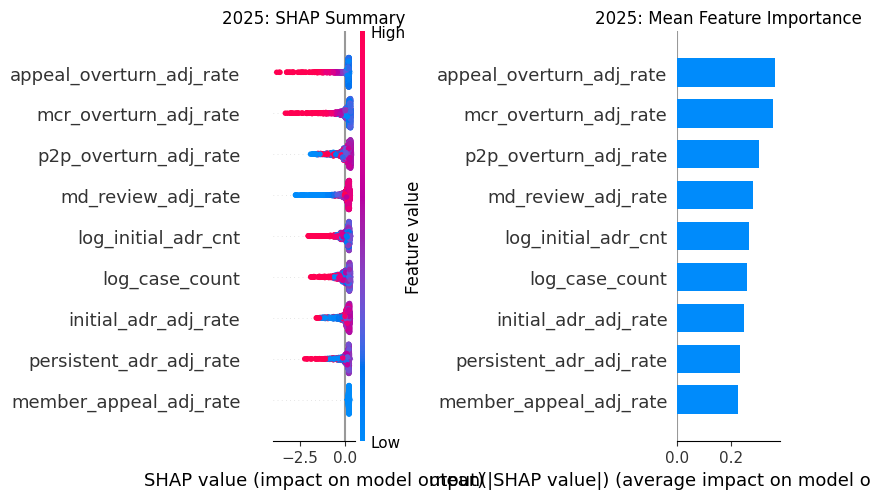

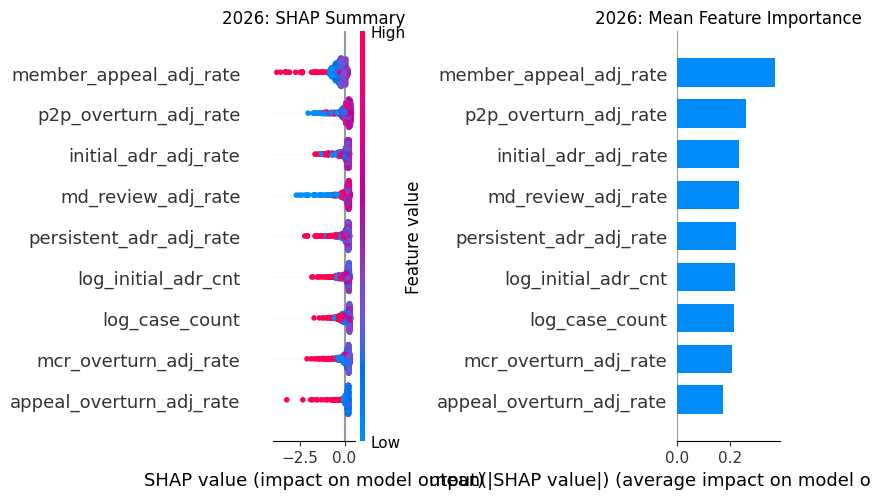

In [35]:
# =============================================================================
# SHAP SUMMARY PLOTS — split by year for readability
# =============================================================================
for yr in ["2025", "2026"]:
    mask = (df_pooled["year"] == yr).values
    fig, axes = plt.subplots(1, 2, figsize = (16, 5))

    plt.sca(axes[0])
    shap.summary_plot(shap_values[mask], X_pooled[mask], feature_names = iso_kpi, show = False)
    axes[0].set_title(f"{yr}: SHAP Summary")

    plt.sca(axes[1])
    shap.summary_plot(shap_values[mask], X_pooled[mask], feature_names = iso_kpi, plot_type = "bar", show = False)
    axes[1].set_title(f"{yr}: Mean Feature Importance")

    plt.tight_layout()
    plt.show()

In [36]:
# =============================================================================
# SHAP FLAGGED HOSPITAL DRIVERS
# =============================================================================
flagged_mask = df_pooled["anomaly_flag"].values
flagged_pos = np.where(flagged_mask)[0]

shap_flagged = pd.DataFrame(
    shap_values[flagged_pos, :],
    columns=iso_kpi,
    index=range(len(flagged_pos))
)
shap_flagged["hospital_group"] = df_pooled.iloc[flagged_pos]["hospital_group"].values
shap_flagged["fin_market"] = df_pooled.iloc[flagged_pos]["fin_market"].values
shap_flagged["year"] = df_pooled.iloc[flagged_pos]["year"].values
shap_flagged["anomaly_rank"] = df_pooled.iloc[flagged_pos]["anomaly_rank"].values

shap_flagged["_driver_col"] = shap_flagged[iso_kpi].idxmin(axis=1)
shap_flagged["shap_driver_value"] = shap_flagged[iso_kpi].min(axis=1)

driver_actual = []
for i, col in enumerate(shap_flagged["_driver_col"]):
    driver_actual.append(df_pooled.iloc[flagged_pos[i]][col])
shap_flagged["driver_actual_value"] = driver_actual

feature_medians = df_pooled[iso_kpi].median()
shap_flagged["driver_direction"] = [
    "high" if v > feature_medians[c] else "low"
    for v, c in zip(shap_flagged["driver_actual_value"], shap_flagged["_driver_col"])
]
shap_flagged["shap_driver"] = shap_flagged["_driver_col"] + " (" + shap_flagged["driver_direction"] + ")"
shap_flagged.drop(columns="_driver_col", inplace=True)

print(f"Flagged: {len(shap_flagged)} hospital-years")
shap_flagged[["hospital_group", "fin_market", "year", "anomaly_rank", "shap_driver", "shap_driver_value", "driver_actual_value"]].sort_values("anomaly_rank")

Flagged: 51 hospital-years


,hospital_group,fin_market,year,anomaly_rank,shap_driver,shap_driver_value,driver_actual_value
46,Atrium Health System,NC,2026,1,member_appeal_adj_rate (high),-3.078578,0.651464
42,ADVOCATE HEALTH & HOSPITALS IL,IL,2026,2,md_review_adj_rate (low),-2.197607,0.030516
38,NORTH CAROLINA BAPTIST HOSPITAL SYSTEM,NC,2026,3,member_appeal_adj_rate (high),-3.285566,0.631091
22,Ascension MI,MI,2025,4,md_review_adj_rate (low),-1.903269,0.135100
16,JOHNS HOPKINS HEALTH SYSTEM,DC,2025,5,appeal_overturn_adj_rate (high),-2.903463,0.049326
28,Stanford Health Hospital,CA-N,2025,6,appeal_overturn_adj_rate (high),-2.887154,0.056933
18,Froedtert,WI,2025,7,mcr_overturn_adj_rate (high),-2.770421,0.153582
26,OKLAHOMA SPINE HOSPITAL,OK,2025,8,appeal_overturn_adj_rate (high),-3.244283,0.106275
5,Steward,FL,2025,9,persistent_adr_adj_rate (high),-1.841510,0.385872
8,ADVOCATE HEALTH & HOSPITALS IL,IL,2025,10,md_review_adj_rate (low),-2.351308,0.027064



Ascension MI | Rank #4 (2025)


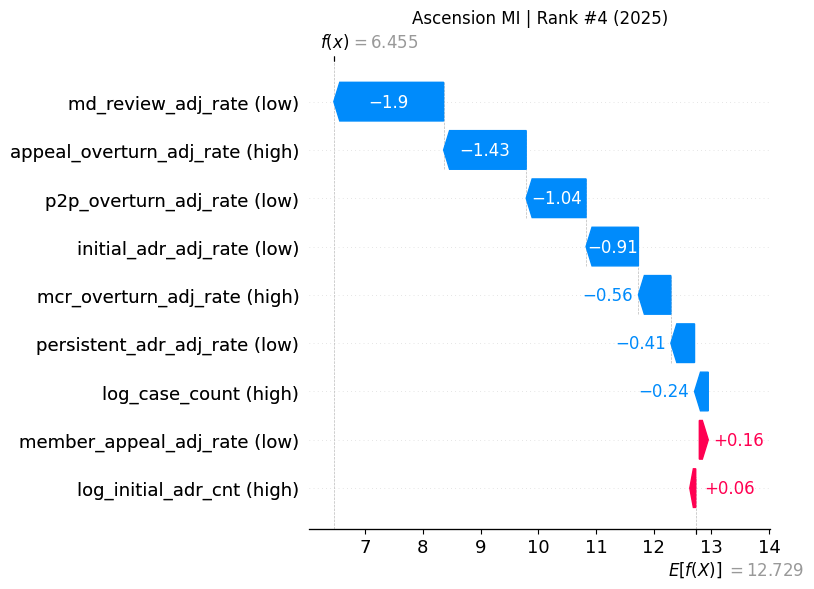


JOHNS HOPKINS HEALTH SYSTEM | Rank #5 (2025)


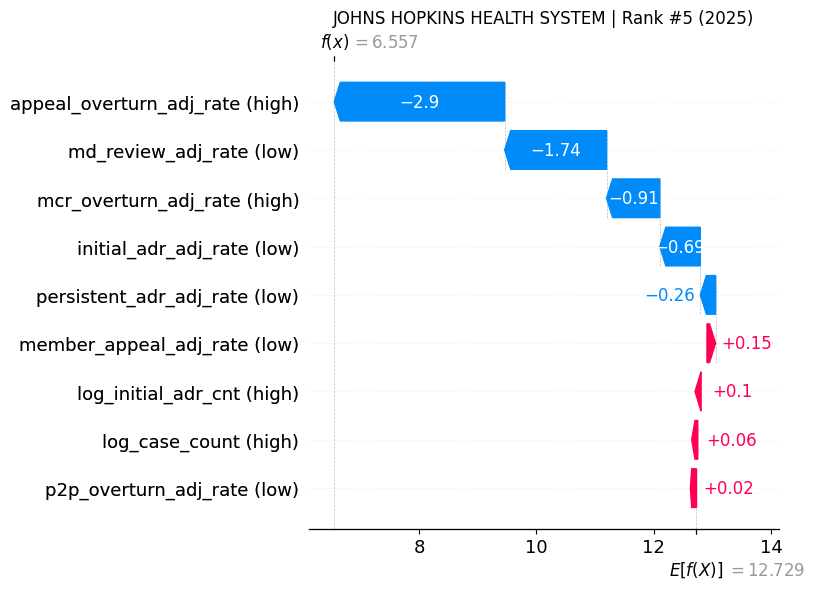


Stanford Health Hospital | Rank #6 (2025)


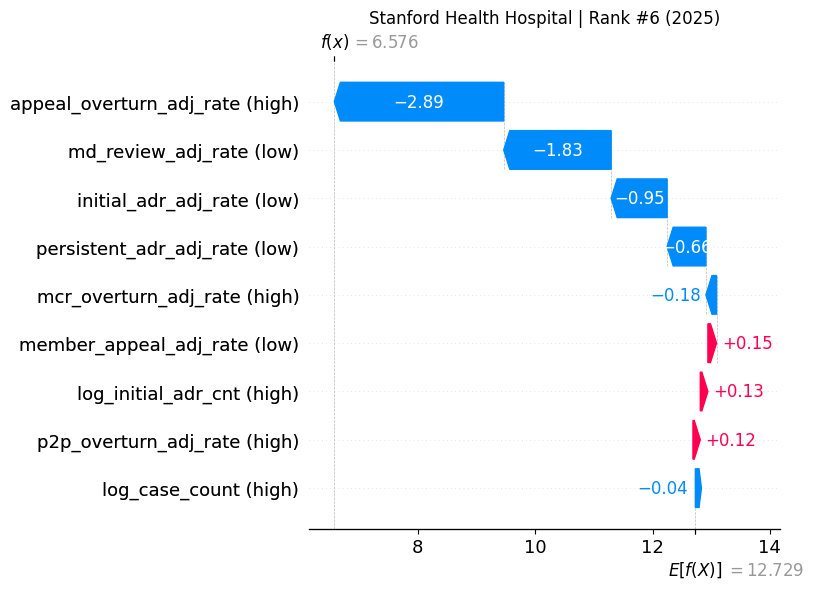


Froedtert | Rank #7 (2025)


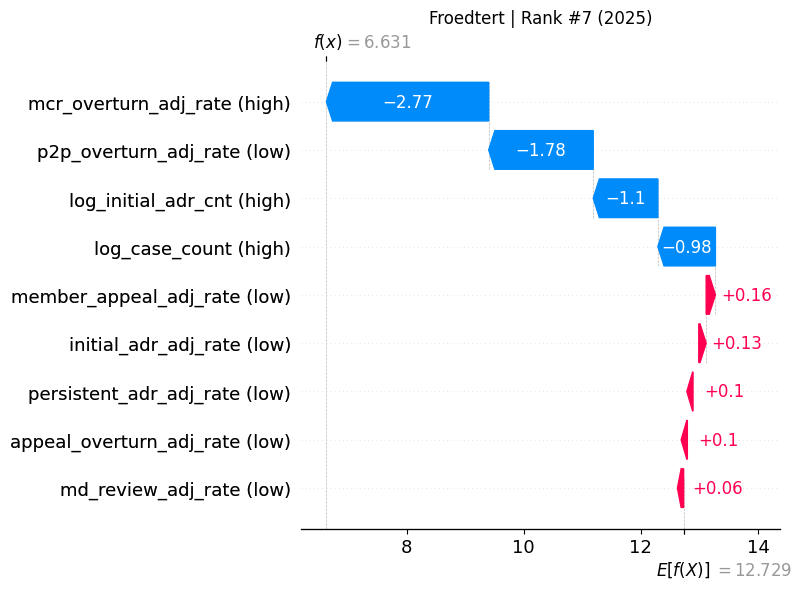


OKLAHOMA SPINE HOSPITAL | Rank #8 (2025)


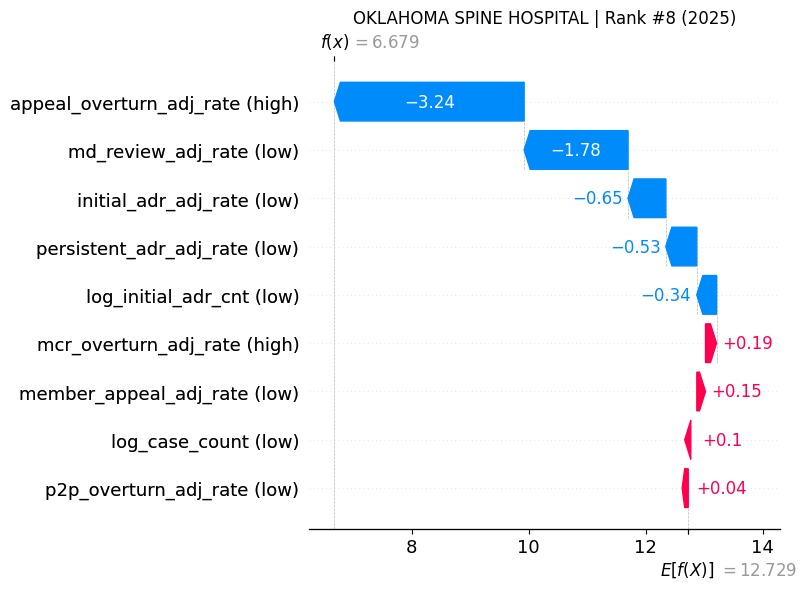


Atrium Health System | Rank #1 (2026)


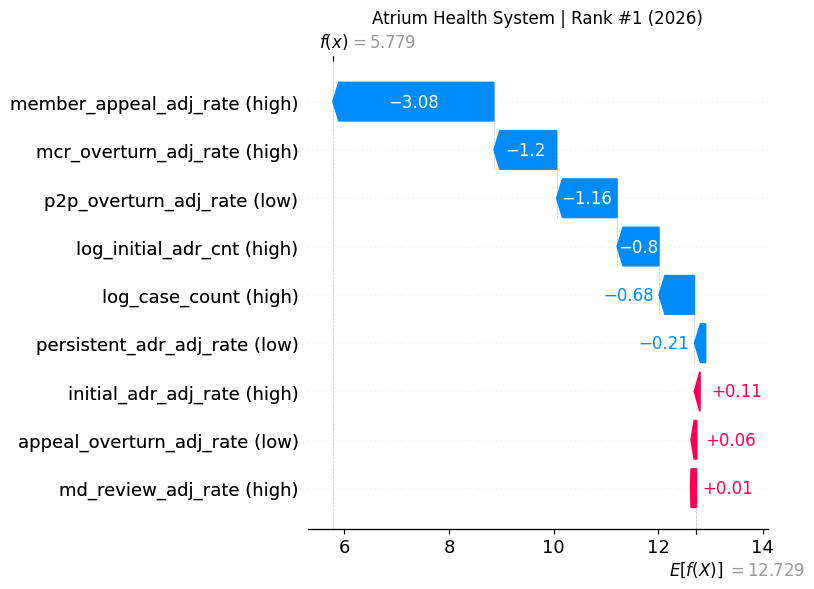


ADVOCATE HEALTH & HOSPITALS IL | Rank #2 (2026)


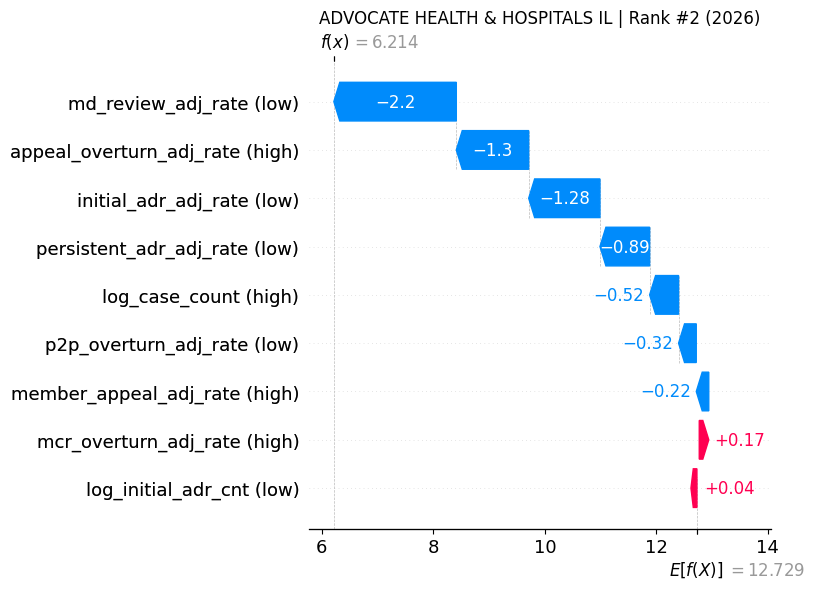


NORTH CAROLINA BAPTIST HOSPITAL SYSTEM | Rank #3 (2026)


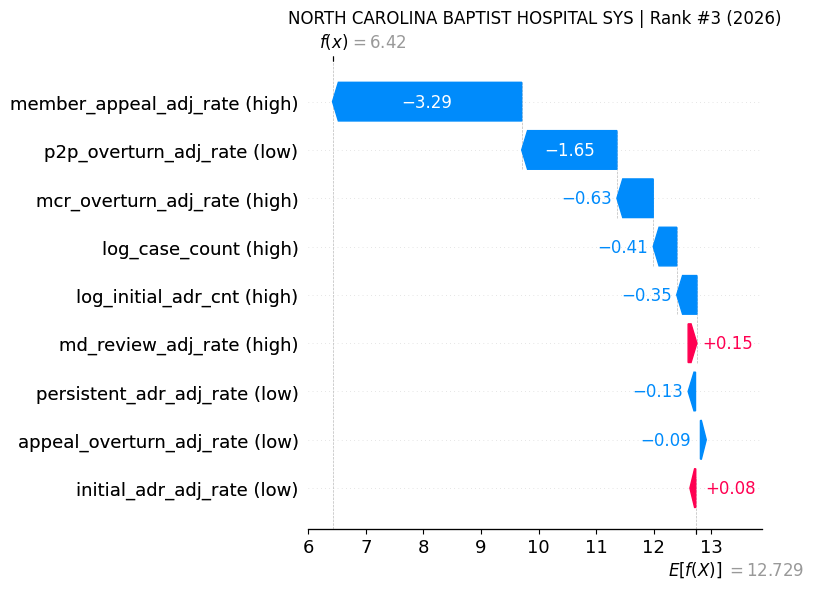


HEALTH SERVICES OF CENTRAL GA | Rank #13 (2026)


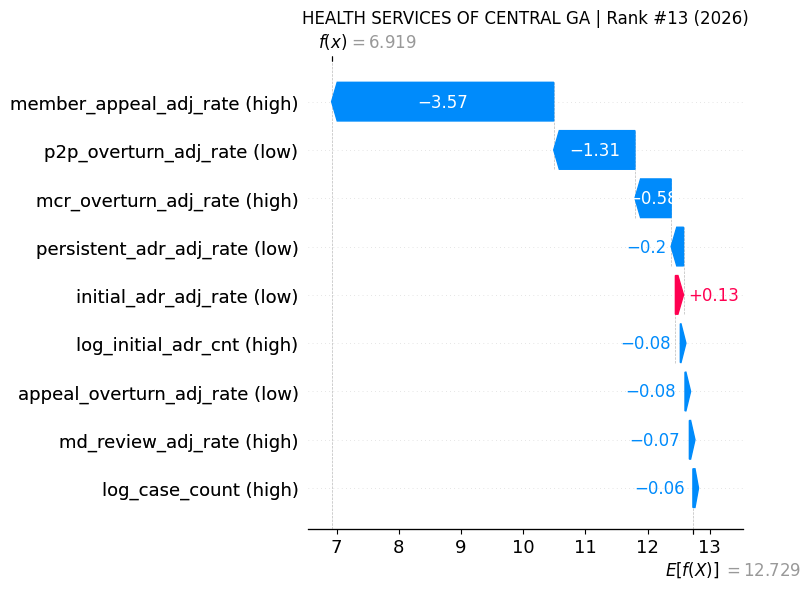


FLOYD HEALTHCARE MANAGEMENT | Rank #15 (2026)


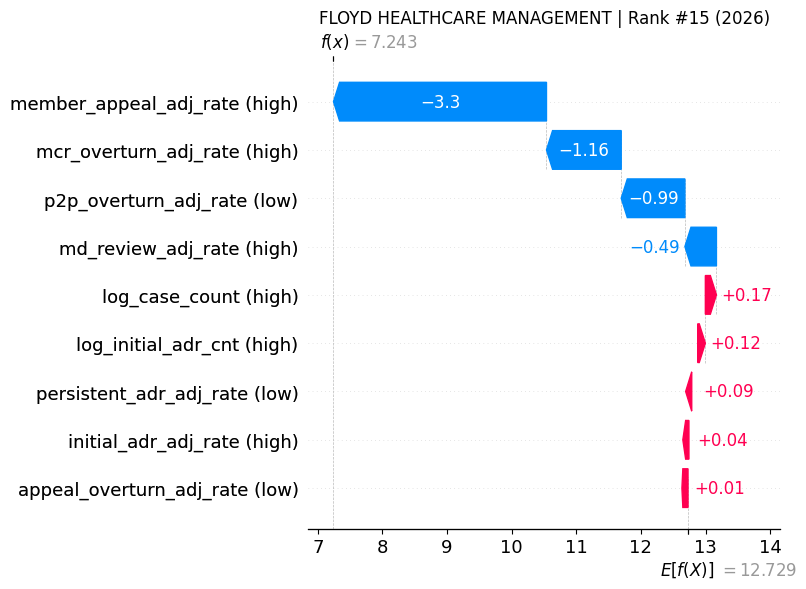

In [37]:
# =============================================================================
# SHAP WATERFALL — TOP 5 per year (ordered by anomaly_rank)
# =============================================================================
base_val = float(explainer.expected_value) if np.ndim(explainer.expected_value) == 0 else float(explainer.expected_value[0])
feature_medians = df_pooled[iso_kpi].median()

for yr in ["2025", "2026"]:
    yr_mask = (df_pooled["year"] == yr).values
    flag_mask = df_pooled["anomaly_flag"].values
    name_mask = df_pooled["hospital_group"].notna().values
    combined = yr_mask & flag_mask & name_mask

    candidates = df_pooled.iloc[np.where(combined)[0]].copy()
    candidates["_pos"] = np.where(combined)[0]
    top5 = candidates.nsmallest(5, "anomaly_rank")

    for _, row in top5.iterrows():
        pos = int(row["_pos"])
        hospital_name = row["hospital_group"]
        rank = int(row["anomaly_rank"])

        feat_labels = [
            f"{col} ({'high' if df_pooled.iloc[pos][col] > feature_medians[col] else 'low'})"
            for col in iso_kpi
        ]

        print(f"\n{'=' * 60}")
        print(f"{hospital_name} | Rank #{rank} ({yr})")
        print(f"{'=' * 60}")

        explanation = shap.Explanation(
            values=shap_values[pos],
            base_values=base_val,
            feature_names=feat_labels
        )
        shap.waterfall_plot(explanation, show=False)
        plt.title(f"{hospital_name[:35]} | Rank #{rank} ({yr})")
        plt.tight_layout()
        plt.show()

In [38]:
# =============================================================================
# OUTPUT ASSEMBLY
# =============================================================================
adj_rate_cols = [
    "initial_adr_adj_rate", "persistent_adr_adj_rate", "p2p_overturn_adj_rate",
    "appeal_overturn_adj_rate", "mcr_overturn_adj_rate", "md_review_adj_rate",
    "member_appeal_adj_rate"
]
all_rate_cols = [
    "initial_adr_rate", "persistent_adr_rate", "p2p_overturn_rate",
    "appeal_overturn_rate", "mcr_overturn_rate", "md_review_rate",
]
adj_to_raw = dict(zip(adj_rate_cols[:6], all_rate_cols))

driver_col_raw = shap_flagged["shap_driver"].str.replace(r" \((high|low)\)$", "", regex=True)
driver_direction = shap_flagged["driver_direction"]

df_pooled["driver"] = ""
df_pooled["direction"] = ""
df_pooled.iloc[flagged_pos, df_pooled.columns.get_loc("driver")] = driver_col_raw.values
df_pooled.iloc[flagged_pos, df_pooled.columns.get_loc("direction")] = driver_direction.values

df_pooled["reason"] = np.where(
    df_pooled["anomaly_flag"],
    df_pooled["driver"] + " (" + df_pooled["direction"] + ")",
    ""
)

adj_medians = df_pooled[iso_kpi].median()
raw_med_case = df_pooled["case_count"].median()
raw_med_adr = df_pooled["initial_adr_cnt"].median()

df_pooled["driver_value"] = np.nan
df_pooled["driver_adj_median"] = np.nan
df_pooled["driver_raw_median"] = np.nan
df_pooled["driver_dev_pct"] = np.nan

mask = df_pooled["anomaly_flag"] & (df_pooled["driver"] == "log_case_count")
df_pooled.loc[mask, "driver_value"] = df_pooled.loc[mask, "case_count"]
df_pooled.loc[mask, "driver_adj_median"] = raw_med_case
df_pooled.loc[mask, "driver_raw_median"] = raw_med_case
df_pooled.loc[mask, "driver_dev_pct"] = (df_pooled.loc[mask, "case_count"] - raw_med_case) / raw_med_case

mask = df_pooled["anomaly_flag"] & (df_pooled["driver"] == "log_initial_adr_cnt")
df_pooled.loc[mask, "driver_value"] = df_pooled.loc[mask, "initial_adr_cnt"]
df_pooled.loc[mask, "driver_adj_median"] = raw_med_adr
df_pooled.loc[mask, "driver_raw_median"] = raw_med_adr
df_pooled.loc[mask, "driver_dev_pct"] = (df_pooled.loc[mask, "initial_adr_cnt"] - raw_med_adr) / raw_med_adr

for ac in adj_rate_cols:
    mask = df_pooled["anomaly_flag"] & (df_pooled["driver"] == ac)
    if mask.any():
        df_pooled.loc[mask, "driver_value"] = df_pooled.loc[mask, ac]
        df_pooled.loc[mask, "driver_adj_median"] = adj_medians[ac]
        raw_col = adj_to_raw.get(ac)
        if raw_col and raw_col in df_pooled.columns:
            raw_meds = df_pooled[raw_col].median()
            df_pooled.loc[mask, "driver_raw_median"] = raw_meds
        else:
            df_pooled.loc[mask, "driver_raw_median"] = adj_medians[ac]
        df_pooled.loc[mask, "driver_dev_pct"] = (df_pooled.loc[mask, ac] - adj_medians[ac]) / adj_medians[ac]

all_count_cols = list(set(count_cols_25 + count_cols_26))
all_rate_cols_full = list(set(rate_cols_25 + rate_cols_26))

for col in all_count_cols + all_rate_cols_full + iso_kpi:
    if col not in df_pooled.columns:
        df_pooled[col] = 0.0

output_cols = [
    "hospital_group", "fin_market", "year",
    *[c for c in all_count_cols if c in df_pooled.columns],
    *[c for c in all_rate_cols_full if c in df_pooled.columns],
    *iso_kpi,
    "anomaly_score", "anomaly_rank", "percentile_rank", "anomaly_flag",
    "driver", "direction", "reason",
    "driver_value", "driver_adj_median", "driver_raw_median", "driver_dev_pct"
]
df_output = (
    df_pooled[[c for c in output_cols if c in df_pooled.columns]]
    .sort_values("anomaly_score")
    .reset_index(drop=True)
)

print(f"Output: {df_output.shape[0]} rows | Flagged: {df_output['anomaly_flag'].sum()}")
print(f"  2025: {(df_output['year'] == '2025').sum()} rows ({((df_output['year'] == '2025') & df_output['anomaly_flag']).sum()} flagged)")
print(f"  2026: {(df_output['year'] == '2026').sum()} rows ({((df_output['year'] == '2026') & df_output['anomaly_flag']).sum()} flagged)")
df_output[df_output["anomaly_flag"]]

Output: 2016 rows | Flagged: 51
  2025: 1226 rows (34 flagged)
  2026: 790 rows (17 flagged)


,hospital_group,fin_market,year,member_appeal_cnt,initial_adr_cnt,p2p_ovrtn_cnt,case_count,persistent_adr_cnt,appeal_ovrtn_cnt,mcr_ovrtn_cnt,...,anomaly_rank,percentile_rank,anomaly_flag,driver,direction,reason,driver_value,driver_adj_median,driver_raw_median,driver_dev_pct
0,Atrium Health System,NC,2026,1012.0,1506,165,4647,380,3,109,...,1,0.0005,True,member_appeal_adj_rate,high,member_appeal_adj_rate (high),0.651464,0.033556,0.033556,18.414064
1,ADVOCATE HEALTH & HOSPITALS IL,IL,2026,2.0,29,0,2555,22,2,1,...,2,0.0010,True,md_review_adj_rate,low,md_review_adj_rate (low),0.030516,0.711887,0.723656,-0.957134
2,NORTH CAROLINA BAPTIST HOSPITAL SYSTEM,NC,2026,483.0,718,7,2765,253,0,40,...,3,0.0015,True,member_appeal_adj_rate,high,member_appeal_adj_rate (high),0.631091,0.033556,0.033556,17.806935
3,Ascension MI,MI,2025,NaN,93,0,1330,65,4,6,...,4,0.0020,True,md_review_adj_rate,low,md_review_adj_rate (low),0.135100,0.711887,0.723656,-0.810222
4,JOHNS HOPKINS HEALTH SYSTEM,DC,2025,NaN,59,14,527,33,5,5,...,5,0.0025,True,appeal_overturn_adj_rate,high,appeal_overturn_adj_rate (high),0.049326,0.003922,0.000000,11.576874
5,Stanford Health Hospital,CA-N,2025,NaN,62,27,753,25,6,3,...,6,0.0030,True,appeal_overturn_adj_rate,high,appeal_overturn_adj_rate (high),0.056933,0.003922,0.000000,13.516563
6,Froedtert,WI,2025,NaN,2264,0,8223,1054,6,354,...,7,0.0035,True,mcr_overturn_adj_rate,high,mcr_overturn_adj_rate (high),0.153582,0.020431,0.013063,6.517085
7,OKLAHOMA SPINE HOSPITAL,OK,2025,NaN,10,0,138,2,6,0,...,8,0.0040,True,appeal_overturn_adj_rate,high,appeal_overturn_adj_rate (high),0.106275,0.003922,0.000000,26.097585
8,Steward,FL,2025,NaN,1478,211,2709,1057,17,83,...,9,0.0045,True,persistent_adr_adj_rate,high,persistent_adr_adj_rate (high),0.385872,0.154654,0.154433,1.495063
9,ADVOCATE HEALTH & HOSPITALS IL,IL,2025,NaN,78,27,7393,42,2,1,...,10,0.0050,True,md_review_adj_rate,low,md_review_adj_rate (low),0.027064,0.711887,0.723656,-0.961983


In [ ]:
# # =============================================================================
# # WRITE TO SNOWFLAKE
# # =============================================================================
# from sqlalchemy import create_engine
# from snowflake.sqlalchemy import URL

# engine_write = create_engine(URL(
#     account       = "UHG-UHGDWAAS",
#     user          = "KHANG.NGUYEN@UHC.COM",
#     authenticator = "externalbrowser",
#     role          = "AZU_SDRP_VING_PRD_DEVELOPER_ROLE",
#     warehouse     = "VING_PRD_MNR_HCE_DATAINFRA_WH",
#     database      = "VING_PRD_TREND_DB",
#     schema        = "TMP_1M"
# ))

# df_write = df_output.copy()
# df_write.columns = [c.upper() for c in df_write.columns]

# df_write.to_sql(
#     "kn_loc_if_outlier_hospitals_mnr_2025_2026",
#     engine_write,
#     schema = "TMP_1M",
#     if_exists = "replace",
#     index = False
# )

# engine_write.dispose()

# print(f"Wrote {len(df_write)} rows to TMP_1M.KN_LOC_IF_OUTLIER_HOSPITALS_MNR_2025_2026")
# print(f"  2025: {(df_write['YEAR'] == '2025').sum()} rows")
# print(f"  2026: {(df_write['YEAR'] == '2026').sum()} rows")

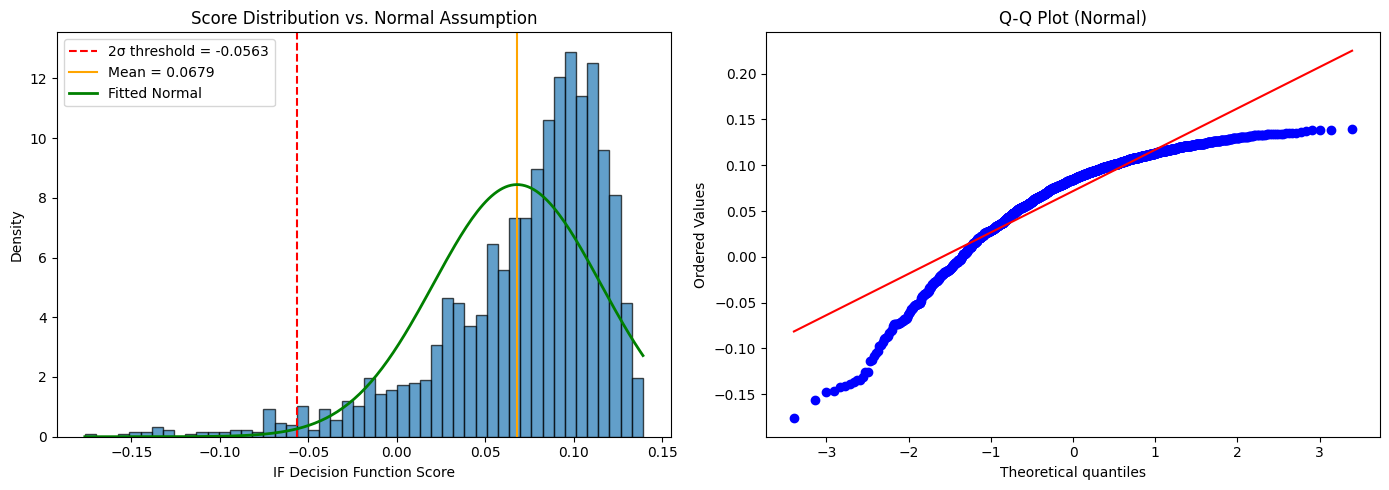

Shapiro-Wilk: W=0.8760, p=2.3697e-37
Skewness: -1.534 (normal=0)
Excess Kurtosis: 2.933 (normal=0)

If p < 0.05 or |skew| > 0.5, consider percentile-based threshold instead of 2σ.
  Percentile 2.5th: -0.0563
  Current 2σ threshold: -0.0563
  Would flag (2.5th pct): 51 hospitals
  Currently flags (2σ):   51 hospitals


In [39]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(scores, bins=50, edgecolor='black', alpha=0.7, density=True)
axes[0].axvline(threshold, color='red', linestyle='--', label=f'2σ threshold = {threshold:.4f}')
axes[0].axvline(score_mean, color='orange', linestyle='-', label=f'Mean = {score_mean:.4f}')
xs = np.linspace(scores.min(), scores.max(), 200)
axes[0].plot(xs, stats.norm.pdf(xs, score_mean, score_std), 'g-', lw=2, label='Fitted Normal')
axes[0].set_xlabel('IF Decision Function Score')
axes[0].set_ylabel('Density')
axes[0].set_title('Score Distribution vs. Normal Assumption')
axes[0].legend()

stats.probplot(scores, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot (Normal)')

plt.tight_layout()
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(scores[:5000]) if len(scores) > 5000 else stats.shapiro(scores)
skewness = stats.skew(scores)
kurtosis_val = stats.kurtosis(scores)

print(f"Shapiro-Wilk: W={shapiro_stat:.4f}, p={shapiro_p:.4e}")
print(f"Skewness: {skewness:.3f} (normal=0)")
print(f"Excess Kurtosis: {kurtosis_val:.3f} (normal=0)")
print(f"\nIf p < 0.05 or |skew| > 0.5, consider percentile-based threshold instead of 2σ.")
print(f"  Percentile 2.5th: {np.percentile(scores, 2.5):.4f}")
print(f"  Current 2σ threshold: {threshold:.4f}")
print(f"  Would flag (2.5th pct): {(scores < np.percentile(scores, 2.5)).sum()} hospitals")
print(f"  Currently flags (2σ):   {(scores < threshold).sum()} hospitals")

In [41]:
# =============================================================================
# VERIFY: member_appeal_adj_rate SHAP contribution ≈ 0 for 2025 rows
# =============================================================================
# If imputation worked correctly, the constant-value feature should produce
# negligible SHAP values for 2025 rows (IF can't gain information from a
# feature with zero variance within that subset).
# =============================================================================

member_appeal_idx = iso_kpi.index("member_appeal_adj_rate")
mask_2025 = (df_pooled["year"] == "2025").values
mask_2026 = (df_pooled["year"] == "2026").values

shap_ma_2025 = shap_values[mask_2025, member_appeal_idx]
shap_ma_2026 = shap_values[mask_2026, member_appeal_idx]

print("=" * 60)
print("member_appeal_adj_rate SHAP — 2025 (imputed constant)")
print("=" * 60)
print(f"  Mean:   {shap_ma_2025.mean():.6f}")
print(f"  Std:    {shap_ma_2025.std():.6f}")
print(f"  Min:    {shap_ma_2025.min():.6f}")
print(f"  Max:    {shap_ma_2025.max():.6f}")
print(f"  |Max|:  {np.abs(shap_ma_2025).max():.6f}")
print()
print("=" * 60)
print("member_appeal_adj_rate SHAP — 2026 (actual variation)")
print("=" * 60)
print(f"  Mean:   {shap_ma_2026.mean():.6f}")
print(f"  Std:    {shap_ma_2026.std():.6f}")
print(f"  Min:    {shap_ma_2026.min():.6f}")
print(f"  Max:    {shap_ma_2026.max():.6f}")
print(f"  |Max|:  {np.abs(shap_ma_2026).max():.6f}")
print()

# Threshold: if max |SHAP| for 2025 is < 0.001 (relative to typical SHAP magnitudes)
# then the imputation is working as intended
max_abs_2025 = np.abs(shap_ma_2025).max()
overall_shap_scale = np.abs(shap_values).mean()
ratio = max_abs_2025 / overall_shap_scale if overall_shap_scale > 0 else 0

print("=" * 60)
print("VERDICT")
print("=" * 60)
print(f"  Max |SHAP| for 2025 member_appeal: {max_abs_2025:.6f}")
print(f"  Overall mean |SHAP| across all features: {overall_shap_scale:.6f}")
print(f"  Ratio (2025 member_appeal / overall): {ratio:.4f}")
if ratio < 0.05:
    print("  ✓ PASS — member_appeal contribution is negligible for 2025 rows")
    print("    (imputation to global rate effectively neutralizes this feature)")
else:
    print("  ✗ WARN — member_appeal SHAP is NOT negligible for 2025 rows")
    print("    Consider dropping this feature from pooled model or investigating further")
    print(f"    {(np.abs(shap_ma_2025) > 0.001).sum()} of {mask_2025.sum()} rows have |SHAP| > 0.001")

member_appeal_adj_rate SHAP — 2025 (imputed constant)
  Mean:   0.223471
  Std:    0.017248
  Min:    0.146567
  Max:    0.258129
  |Max|:  0.258129

member_appeal_adj_rate SHAP — 2026 (actual variation)
  Mean:   -0.345115
  Std:    0.475833
  Min:    -3.793604
  Max:    0.214061
  |Max|:  3.793604

VERDICT
  Max |SHAP| for 2025 member_appeal: 0.258129
  Overall mean |SHAP| across all features: 0.264752
  Ratio (2025 member_appeal / overall): 0.9750
  ✗ WARN — member_appeal SHAP is NOT negligible for 2025 rows
    Consider dropping this feature from pooled model or investigating further
    1226 of 1226 rows have |SHAP| > 0.001
